# Tubule Segmentation to Harmonized Tubule by Gene Matrix

## Part 1: Bin to Tubule

Raw tubule segmentations from `data/segmentations/raw_segmentation` were matched to their corresponding Visium datasets in `data/visium_data`. For each sample, Visium spots were assigned to segmented tubule polygons in full-resolution image coordinates using a fixed scalefactor of 1, and spot-level counts were summed within each tubule to generate a sparse tubule-by-gene expression matrix.

Only in-tissue spots with matched barcodes in both the Visium expression matrix and spatial coordinate table were considered. Tubule-level metadata including centroid coordinates, feature index, and contributing spot count were retained in the output AnnData object. Each sample was written to `data/tubule_by_gene` as an `.h5ad` file, with no additional intermediate outputs saved.


In [1]:
from __future__ import annotations

import concurrent.futures as cf
import json
import multiprocessing as mp
import os
from pathlib import Path

for env_var in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ.setdefault(env_var, "1")

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import shapely
from scipy import sparse
from shapely.geometry import Point, shape
from shapely.strtree import STRtree

cwd = Path.cwd().resolve()
if cwd.name == "pseudospace_reconstruction":
    PROJECT_DIR = cwd
elif (cwd / "pseudospace_reconstruction").exists():
    PROJECT_DIR = (cwd / "pseudospace_reconstruction").resolve()
else:
    raise FileNotFoundError("Could not locate the pseudospace_reconstruction project directory")

DATA_DIR = PROJECT_DIR / "data"
RAW_SEGMENTATION_DIR = DATA_DIR / "segmentations" / "raw_segmentation"
VISIUM_DIR = DATA_DIR / "visium_data"
TUBULE_BY_GENE_DIR = DATA_DIR / "tubule_by_gene"
TUBULE_BY_GENE_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_ALIASES = {
    "HUK1_MED1": "HUK1_MED",
}

def sample_from_segmentation(path: Path) -> str:
    return path.name.replace("_tubules_processed_caleb.geojson", "")

def visium_sample_for(segmentation_sample: str) -> str:
    return SAMPLE_ALIASES.get(segmentation_sample, segmentation_sample)

def standardize_positions(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    lower_map = {str(col).strip().lower(): col for col in df.columns}
    rename = {}
    candidates = {
        "barcode": ["barcode", "barcodes"],
        "in_tissue": ["in_tissue"],
        "array_row": ["array_row"],
        "array_col": ["array_col"],
        "pxl_row_in_fullres": ["pxl_row_in_fullres", "pxl_row_in_full_res"],
        "pxl_col_in_fullres": ["pxl_col_in_fullres", "pxl_col_in_full_res"],
    }
    for target, names in candidates.items():
        for name in names:
            if name in lower_map:
                rename[lower_map[name]] = target
                break
    df = df.rename(columns=rename)
    expected = ["barcode", "in_tissue", "array_row", "array_col", "pxl_row_in_fullres", "pxl_col_in_fullres"]
    if not set(expected).issubset(df.columns):
        working = df.copy()
        unnamed = [col for col in working.columns if str(col).lower().startswith("unnamed")]
        if unnamed and len(working.columns) >= 7:
            working = working.drop(columns=unnamed[:1])
        if len(working.columns) >= 6:
            working = working.iloc[:, :6].copy()
            working.columns = expected
            df = working
        else:
            raise ValueError("Could not standardize tissue positions columns")
    df["barcode"] = df["barcode"].astype(str)
    df["in_tissue"] = pd.to_numeric(df["in_tissue"], errors="coerce").fillna(0).astype(int)
    df["array_row"] = pd.to_numeric(df["array_row"], errors="coerce")
    df["array_col"] = pd.to_numeric(df["array_col"], errors="coerce")
    df["pxl_row_in_fullres"] = pd.to_numeric(df["pxl_row_in_fullres"], errors="coerce")
    df["pxl_col_in_fullres"] = pd.to_numeric(df["pxl_col_in_fullres"], errors="coerce")
    return df.set_index("barcode")

def load_positions(spatial_dir: Path) -> pd.DataFrame:
    parquet_path = spatial_dir / "tissue_positions.parquet"
    csv_path = spatial_dir / "tissue_positions.csv"
    if parquet_path.exists():
        try:
            df = pd.read_parquet(parquet_path)
        except Exception:
            df = None
        if df is not None:
            return standardize_positions(df)
    if csv_path.exists():
        try:
            df = pd.read_csv(csv_path)
            if "barcode" not in {str(c).lower() for c in df.columns}:
                df = pd.read_csv(csv_path, header=None)
        except Exception:
            df = pd.read_csv(csv_path, header=None)
        return standardize_positions(df)
    raise FileNotFoundError(f"Could not find tissue positions in {spatial_dir}")

def load_visium_spots(visium_sample_dir: Path) -> ad.AnnData:
    matrix_path = visium_sample_dir / "filtered_feature_bc_matrix.h5"
    spatial_dir = visium_sample_dir / "spatial"
    adata = sc.read_10x_h5(str(matrix_path))
    adata.var_names_make_unique()
    positions = load_positions(spatial_dir)
    positions = positions[~positions.index.duplicated(keep="first")]
    positions = positions.reindex(adata.obs_names)
    valid = positions["in_tissue"].notna().to_numpy()
    adata = adata[valid].copy()
    positions = positions.loc[adata.obs_names].copy()
    adata.obs = pd.concat([adata.obs, positions], axis=1)
    adata = adata[adata.obs["in_tissue"] > 0].copy()
    return adata

def load_raw_segments(segmentation_path: Path):
    payload = json.loads(segmentation_path.read_text())
    features = payload.get("features", [])
    records = []
    for feature_index, feature in enumerate(features):
        geometry = feature.get("geometry")
        if not geometry:
            continue
        try:
            polygon = shape(geometry)
        except Exception:
            continue
        if polygon.is_empty:
            continue
        if not polygon.is_valid:
            polygon = polygon.buffer(0)
        if polygon.is_empty or polygon.area <= 0:
            continue
        centroid = polygon.centroid
        unit_id = feature.get("properties", {}).get("id", f"unit_{feature_index}")
        records.append({
            "feature_index": feature_index,
            "geometry": polygon,
            "unit_id": str(unit_id),
            "x_centroid": float(centroid.x),
            "y_centroid": float(centroid.y),
        })
    return records

def assign_spots_to_units(spot_adata: ad.AnnData, records: list[dict]):
    if not records or spot_adata.n_obs == 0:
        return np.array([], dtype=np.int32), np.array([], dtype=np.int32)
    geometries = [record["geometry"] for record in records]
    tree = STRtree(geometries)
    coords = spot_adata.obs[["pxl_col_in_fullres", "pxl_row_in_fullres"]].to_numpy(dtype=np.float64, copy=False)
    unit_ids = np.full(spot_adata.n_obs, -1, dtype=np.int32)
    try:
        point_array = shapely.points(coords[:, 0], coords[:, 1])
        matches = tree.query(point_array, predicate="covered_by")
        if matches.size:
            point_idx = matches[0]
            geom_idx = matches[1].astype(np.int32, copy=False)
            order = np.argsort(point_idx, kind="stable")
            point_idx = point_idx[order]
            geom_idx = geom_idx[order]
            first_mask = np.empty(point_idx.shape[0], dtype=bool)
            first_mask[0] = True
            first_mask[1:] = point_idx[1:] != point_idx[:-1]
            unit_ids[point_idx[first_mask]] = geom_idx[first_mask]
            assigned_spots = np.flatnonzero(unit_ids >= 0)
            return unit_ids, assigned_spots.astype(np.int32, copy=False)
    except Exception:
        pass
    geom_lookup = {id(geom): idx for idx, geom in enumerate(geometries)}
    for spot_index, (x, y) in enumerate(coords):
        point = Point(float(x), float(y))
        candidates = tree.query(point)
        for candidate in candidates:
            if isinstance(candidate, (int, np.integer)):
                geom_index = int(candidate)
                polygon = geometries[geom_index]
            else:
                polygon = candidate
                geom_index = geom_lookup[id(candidate)]
            if polygon.covers(point):
                unit_ids[spot_index] = geom_index
                break
    assigned_spots = np.flatnonzero(unit_ids >= 0)
    return unit_ids, assigned_spots.astype(np.int32, copy=False)

def build_unit_adata(sample_name: str, segmentation_path: Path, visium_sample_dir: Path) -> ad.AnnData:
    spot_adata = load_visium_spots(visium_sample_dir)
    records = load_raw_segments(segmentation_path)
    unit_ids, assigned_spots = assign_spots_to_units(spot_adata, records)
    obs = pd.DataFrame(
        {
            "sample": sample_name,
            "feature_index": [record["feature_index"] for record in records],
            "x_centroid": [record["x_centroid"] for record in records],
            "y_centroid": [record["y_centroid"] for record in records],
            "n_spots": 0,
        },
        index=[record["unit_id"] for record in records],
    )
    if len(records) == 0 or len(assigned_spots) == 0:
        return ad.AnnData(X=sparse.csr_matrix((len(records), spot_adata.n_vars), dtype=np.float32), obs=obs, var=spot_adata.var.copy())
    assigned_unit_ids = unit_ids[assigned_spots]
    assignment = sparse.coo_matrix(
        (
            np.ones(len(assigned_spots), dtype=np.float32),
            (assigned_unit_ids, np.arange(len(assigned_spots), dtype=np.int32)),
        ),
        shape=(len(records), len(assigned_spots)),
        dtype=np.float32,
    ).tocsr()
    unit_counts = assignment @ spot_adata.X[assigned_spots]
    obs["n_spots"] = np.bincount(assigned_unit_ids, minlength=len(records))
    adata = ad.AnnData(X=unit_counts, obs=obs, var=spot_adata.var.copy())
    return adata

def process_sample(segmentation_path_str: str, project_dir_str: str):
    project_dir = Path(project_dir_str)
    segmentation_path = Path(segmentation_path_str)
    sample = sample_from_segmentation(segmentation_path)
    visium_sample = visium_sample_for(sample)
    visium_sample_dir = VISIUM_DIR / visium_sample
    output_path = TUBULE_BY_GENE_DIR / f"{sample}_tubule_by_gene.h5ad"
    adata = build_unit_adata(sample, segmentation_path, visium_sample_dir)
    adata.write(output_path)
    return {
        "sample": sample,
        "visium_sample": visium_sample,
        "units": int(adata.n_obs),
        "genes": int(adata.n_vars),
        "units_with_spots": int((adata.obs["n_spots"] > 0).sum()) if adata.n_obs else 0,
        "output_path": str(output_path.relative_to(project_dir)),
        "status": "ok",
    }

def run_all_samples(project_dir: Path | str, print_report: bool = True):
    project_dir = Path(project_dir).resolve()
    segmentation_paths = sorted(RAW_SEGMENTATION_DIR.glob("*_tubules_processed_caleb.geojson"))
    max_workers = min(len(segmentation_paths), os.cpu_count() or 1)
    rows = []
    if max_workers > 1 and os.name != "nt":
        ctx = mp.get_context("fork")
        with cf.ProcessPoolExecutor(max_workers=max_workers, mp_context=ctx) as executor:
            futures = [executor.submit(process_sample, str(path), str(project_dir)) for path in segmentation_paths]
            for future in cf.as_completed(futures):
                rows.append(future.result())
    else:
        for path in segmentation_paths:
            rows.append(process_sample(str(path), str(project_dir)))
    summary_df = pd.DataFrame(rows).sort_values("sample").reset_index(drop=True)
    if print_report:
        print(f"Tubule-by-gene matrices created for {len(summary_df)} samples using {max_workers} worker(s)")
        print(f"Outputs saved to: {TUBULE_BY_GENE_DIR.relative_to(project_dir)}")
        print()
        for _, row in summary_df.iterrows():
            print(
                f"{row['sample']} -> {row['visium_sample']}: {row['status']} "
                f"({row['units_with_spots']}/{row['units']} units with spots, {row['genes']} genes)"
            )
    return summary_df

tubule_by_gene_summary = run_all_samples(PROJECT_DIR, print_report=True)
tubule_by_gene_summary


/home/edmund/ENTER/envs/tubule_pseudospace_reconstruction/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/edmund/ENTER/envs/tubule_pseudospace_reconstruction/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/edmund/ENTER/envs/tubule_pseudospace_reconstruction/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/edmund/ENTER/envs/tubule_pseudospace_reconstruction/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("va

Tubule-by-gene matrices created for 6 samples using 6 worker(s)
Outputs saved to: data/tubule_by_gene

Ctrl1A2 -> Ctrl1A2: ok (7620/11653 units with spots, 19059 genes)
Ctrl1A4 -> Ctrl1A4: ok (6760/12556 units with spots, 19059 genes)
HUK1_COR1 -> HUK1_COR1: ok (4548/6294 units with spots, 18132 genes)
HUK1_MED1 -> HUK1_MED: ok (5463/10836 units with spots, 18132 genes)
IR2A2 -> IR2A2: ok (10664/15030 units with spots, 19059 genes)
IR2A4 -> IR2A4: ok (11241/15902 units with spots, 19059 genes)


,sample,visium_sample,units,genes,units_with_spots,output_path,status
0,Ctrl1A2,Ctrl1A2,11653,19059,7620,data/tubule_by_gene/Ctrl1A2_tubule_by_gene.h5ad,ok
1,Ctrl1A4,Ctrl1A4,12556,19059,6760,data/tubule_by_gene/Ctrl1A4_tubule_by_gene.h5ad,ok
2,HUK1_COR1,HUK1_COR1,6294,18132,4548,data/tubule_by_gene/HUK1_COR1_tubule_by_gene.h5ad,ok
3,HUK1_MED1,HUK1_MED,10836,18132,5463,data/tubule_by_gene/HUK1_MED1_tubule_by_gene.h5ad,ok
4,IR2A2,IR2A2,15030,19059,10664,data/tubule_by_gene/IR2A2_tubule_by_gene.h5ad,ok
5,IR2A4,IR2A4,15902,19059,11241,data/tubule_by_gene/IR2A4_tubule_by_gene.h5ad,ok


## Part 2: Quality Control

Tubule-by-gene AnnData objects produced in Part 1 were used as the direct input for quality control. HUK samples were evaluated with the human marker panels and all remaining samples were evaluated with the mouse marker panels. Tubules with zero supporting spots were removed when applicable, basic RNA complexity filters were applied (`total_counts >= 200`, `n_genes_by_counts >= 50`), expression was normalized and log-transformed, region markers were re-validated at a 10% detection threshold, and nephron segment identity scores were computed from per-marker z-scores averaged within each major region.

To identify inconsistent assignments, an entropy-based coherence score was calculated from the regional identity profile using Shannon entropy, and tubules with weak identity signal or incompatible combinations of high-scoring neighboring labels were flagged. Only tubules with `identity_flag == 'ok'` were retained, and the corresponding filtered segmentations were written to `data/segmentations/filtered_segmentations` while a brief per-sample summary was printed in the notebook.


In [2]:
from __future__ import annotations

import concurrent.futures as cf
import json
import multiprocessing as mp
import os
import warnings
from pathlib import Path

for env_var in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ.setdefault(env_var, "1")

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

cwd = Path.cwd().resolve()
if cwd.name == "pseudospace_reconstruction":
    PROJECT_DIR = cwd
elif (cwd / "pseudospace_reconstruction").exists():
    PROJECT_DIR = (cwd / "pseudospace_reconstruction").resolve()
else:
    raise FileNotFoundError("Could not locate the pseudospace_reconstruction project directory")

DATA_DIR = PROJECT_DIR / "data"
RAW_SEGMENTATION_DIR = DATA_DIR / "segmentations" / "raw_segmentation"
FILTERED_SEGMENTATION_DIR = DATA_DIR / "segmentations" / "filtered_segmentations"
TUBULE_BY_GENE_DIR = DATA_DIR / "tubule_by_gene"
FILTERED_SEGMENTATION_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_ALIASES = {
    "HUK1_MED1": "HUK1_MED",
}

major_region_markers_human = {
    "Proximal_Tubule": ["LRP2", "CUBN", "SLC5A2", "SLC5A12", "SLC13A3", "SLC22A6", "SLC34A1"],
    "Thin_Limb": ["AQP1", "CLDN10", "CRYAB", "TACSTD2", "CLDN1"],
    "TAL": ["SLC12A1", "UMOD", "CLDN16", "EGF", "CASR"],
    "DCT": ["SLC12A3", "TRPM6", "CNNM2", "PVALB"],
    "CNT_CD": ["CALB1", "AQP2", "AQP3", "SCNN1B", "SLC4A1", "SLC26A4"],
}

major_region_markers_mouse = {
    "Proximal_Tubule": ["Lrp2", "Cubn", "Slc5a2", "Slc5a12", "Slc13a3", "Slc22a6", "Slc34a1"],
    "Thin_Limb": ["Aqp1", "Cldn10", "Cryab", "Tacstd2", "Cldn1"],
    "TAL": ["Slc12a1", "Umod", "Cldn16", "Egf", "Casr"],
    "DCT": ["Slc12a3", "Trpm6", "Cnnm2", "Pvalb"],
    "CNT_CD": ["Calb1", "Aqp2", "Aqp3", "Scnn1b", "Slc4a1", "Slc26a4"],
}

COMPATIBLE_NEIGHBORS = {
    "Proximal_Tubule": ["Thin_Limb"],
    "Thin_Limb": ["Proximal_Tubule", "TAL"],
    "TAL": ["Thin_Limb", "DCT"],
    "DCT": ["TAL", "CNT_CD"],
    "CNT_CD": ["DCT"],
}


def sample_from_h5ad(path: Path) -> str:
    return path.name.replace("_tubule_by_gene.h5ad", "")


def visium_sample_for(segmentation_sample: str) -> str:
    return SAMPLE_ALIASES.get(segmentation_sample, segmentation_sample)


def organism_for_sample(sample: str) -> str:
    return "human" if sample.startswith("HUK") else "mouse"


def raw_segmentation_path_for(sample: str) -> Path:
    return RAW_SEGMENTATION_DIR / f"{sample}_tubules_processed_caleb.geojson"


def get_expr_and_genes(adata: ad.AnnData):
    if adata.raw is not None:
        expr = adata.raw.X
        genes = list(adata.raw.var_names)
    else:
        expr = adata.X
        genes = list(adata.var_names)

    if hasattr(expr, "toarray"):
        expr = expr.toarray()

    return expr, genes


def profile_markers_detection(
    adata: ad.AnnData,
    marker_dict: dict[str, list[str]],
    min_pct: float = 10.0,
):
    expr, genes = get_expr_and_genes(adata)
    gene_to_idx = {g: i for i, g in enumerate(genes)}
    n_segments = expr.shape[0]

    validated = {}
    pct_map = {}

    all_markers = sorted({g for gl in marker_dict.values() for g in gl})

    for g in all_markers:
        if g not in gene_to_idx:
            pct_map[g] = 0.0
        else:
            col = expr[:, gene_to_idx[g]]
            pct_map[g] = 100.0 * np.sum(col > 0) / n_segments

    for seg, genes_list in marker_dict.items():
        validated[seg] = [
            g for g in genes_list
            if pct_map.get(g, 0.0) >= min_pct
        ]

    return validated, pct_map


def calculate_identity_scores(
    adata: ad.AnnData,
    marker_dict: dict[str, list[str]],
    method: str = "zscore",
):
    expr, genes = get_expr_and_genes(adata)
    gene_to_idx = {g: i for i, g in enumerate(genes)}
    n_segments = expr.shape[0]

    scores = {}

    for seg, markers in marker_dict.items():
        valid = [m for m in markers if m in gene_to_idx]

        if not valid:
            scores[seg] = np.zeros(n_segments)
            continue

        idx = [gene_to_idx[m] for m in valid]
        mat = expr[:, idx]

        if method == "zscore":
            means = mat.mean(axis=0)
            stds = mat.std(axis=0)
            safe_stds = np.where(stds > 0, stds, 1.0)

            z = (mat - means) / safe_stds

            if np.any(stds == 0):
                z[:, stds == 0] = 0.0

            scores[seg] = z.mean(axis=1)
        else:
            scores[seg] = mat.mean(axis=1)

    return pd.DataFrame(scores, index=adata.obs_names)


def assign_identity(scores_df: pd.DataFrame):
    top2 = scores_df.apply(lambda x: x.nlargest(2).index.tolist(), axis=1)
    top2_vals = scores_df.apply(lambda x: x.nlargest(2).values.tolist(), axis=1)

    identity_df = pd.DataFrame(
        {
            "primary_identity": [t[0] for t in top2],
            "secondary_identity": [t[1] if len(t) > 1 else None for t in top2],
            "primary_score": [v[0] for v in top2_vals],
            "secondary_score": [v[1] if len(v) > 1 else 0.0 for v in top2_vals],
        },
        index=scores_df.index,
    )

    return identity_df


def flag_incompatible_segments(
    region_scores: pd.DataFrame,
    incompatible_threshold: float = 0.5,
    weak_identity_threshold: float = 0.25,
):
    flags = []

    for idx in region_scores.index:
        scores = region_scores.loc[idx]
        top2 = scores.nlargest(2)

        primary = top2.index[0]
        secondary = top2.index[1]

        primary_score = top2.values[0]
        secondary_score = top2.values[1]

        compatible = (
            secondary in COMPATIBLE_NEIGHBORS.get(primary, [])
            or secondary == primary
        )

        both_high = (
            primary_score > incompatible_threshold
            and secondary_score > incompatible_threshold
        )

        if primary_score < weak_identity_threshold:
            flags.append("weak_identity")
        elif both_high and not compatible:
            flags.append("incompatible")
        else:
            flags.append("ok")

    return pd.Series(flags, index=region_scores.index)


def run_qc_on_adata(adata: ad.AnnData, organism: str):
    min_counts = 200
    min_genes = 50
    flag_threshold = 0.5
    weak_identity_threshold = 0.25
    marker_validation_pct = 10.0

    warnings_list = []

    summary = {
        "input_segments": int(adata.n_obs),
        "after_spot_filter": 0,
        "after_basic_qc": 0,
        "retained_segments": 0,
        "weak_identity": 0,
        "incompatible": 0,
    }

    adata = adata.copy()

    # Remove segmented tubules with no transcriptomic support.
    if "n_spots" in adata.obs.columns:
        adata = adata[adata.obs["n_spots"] > 0].copy()

    summary["after_spot_filter"] = int(adata.n_obs)

    if adata.n_obs == 0:
        return adata, summary, warnings_list

    # Basic expression QC.
    sc.pp.calculate_qc_metrics(
        adata,
        percent_top=None,
        log1p=False,
        inplace=True,
    )

    adata = adata[adata.obs["total_counts"] >= min_counts].copy()
    adata = adata[adata.obs["n_genes_by_counts"] >= min_genes].copy()

    summary["after_basic_qc"] = int(adata.n_obs)

    if adata.n_obs == 0:
        return adata, summary, warnings_list

    # Store raw counts before normalization.
    adata.layers["counts"] = adata.X.copy()

    # Normalize for marker scoring.
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.raw = adata

    # Choose species-specific marker dictionary.
    if organism == "human":
        major_region_markers = major_region_markers_human
    else:
        major_region_markers = major_region_markers_mouse

    # Validate that marker genes are detected in this sample.
    validated_region_markers, _ = profile_markers_detection(
        adata,
        major_region_markers,
        min_pct=marker_validation_pct,
    )

    for region, markers in validated_region_markers.items():
        if len(markers) == 0:
            warnings_list.append(
                f"region '{region}' has 0 validated markers "
                f"(>= {marker_validation_pct}% expr)"
            )
        elif len(markers) < 2:
            warnings_list.append(
                f"region '{region}' has only {len(markers)} "
                f"validated marker(s): {markers}"
            )

    # Score broad nephron-region identities.
    region_scores = calculate_identity_scores(
        adata,
        validated_region_markers,
        method="zscore",
    )

    identity_df = assign_identity(region_scores)

    adata.obs["primary_identity"] = identity_df["primary_identity"].astype(str)
    adata.obs["secondary_identity"] = identity_df["secondary_identity"].astype(str)
    adata.obs["primary_score"] = identity_df["primary_score"].values
    adata.obs["secondary_score"] = identity_df["secondary_score"].values

    for col in region_scores.columns:
        adata.obs[f"score_{col}"] = region_scores[col].values

    # Flag weak or incompatible broad identities.
    flags = flag_incompatible_segments(
        region_scores,
        incompatible_threshold=flag_threshold,
        weak_identity_threshold=weak_identity_threshold,
    )

    adata.obs["identity_flag"] = flags

    summary["weak_identity"] = int((flags == "weak_identity").sum())
    summary["incompatible"] = int((flags == "incompatible").sum())

    # Final filtered object.
    adata_filtered = adata[adata.obs["identity_flag"] == "ok"].copy()
    summary["retained_segments"] = int(adata_filtered.n_obs)

    return adata_filtered, summary, warnings_list


def save_filtered_segmentation(sample: str, filtered_adata: ad.AnnData) -> int:
    raw_path = raw_segmentation_path_for(sample)
    output_path = FILTERED_SEGMENTATION_DIR / raw_path.name

    payload = json.loads(raw_path.read_text())

    keep_feature_indices = (
        set(filtered_adata.obs["feature_index"].astype(int).tolist())
        if filtered_adata.n_obs
        else set()
    )

    payload["features"] = [
        feature
        for feature_index, feature in enumerate(payload.get("features", []))
        if feature_index in keep_feature_indices
    ]

    output_path.write_text(json.dumps(payload, indent=2))

    return len(payload["features"])


def process_sample(h5ad_path_str: str, project_dir_str: str):
    project_dir = Path(project_dir_str)
    h5ad_path = Path(h5ad_path_str)

    sample = sample_from_h5ad(h5ad_path)
    organism = organism_for_sample(sample)
    visium_sample = visium_sample_for(sample)

    adata = ad.read_h5ad(h5ad_path)

    filtered_adata, qc_summary, warning_messages = run_qc_on_adata(
        adata,
        organism=organism,
    )

    saved_features = save_filtered_segmentation(sample, filtered_adata)

    row = {
        "sample": sample,
        "organism": organism,
        "visium_sample": visium_sample,
        "input_segments": qc_summary["input_segments"],
        "after_spot_filter": qc_summary["after_spot_filter"],
        "after_basic_qc": qc_summary["after_basic_qc"],
        "retained_segments": qc_summary["retained_segments"],
        "weak_identity": qc_summary["weak_identity"],
        "incompatible": qc_summary["incompatible"],
        "filtered_segmentation_file": str(
            (
                FILTERED_SEGMENTATION_DIR
                / f"{sample}_tubules_processed_caleb.geojson"
            ).relative_to(project_dir)
        ),
        "status": (
            "ok"
            if saved_features == qc_summary["retained_segments"]
            else "mismatch_saved_features"
        ),
        "warnings": " | ".join(warning_messages),
    }

    return row


def run_qc_for_all_samples(project_dir: Path | str, print_report: bool = True):
    project_dir = Path(project_dir).resolve()

    h5ad_paths = sorted(TUBULE_BY_GENE_DIR.glob("*_tubule_by_gene.h5ad"))

    max_workers = min(len(h5ad_paths), os.cpu_count() or 1)

    rows = []

    if max_workers > 1 and os.name != "nt":
        ctx = mp.get_context("fork")

        with cf.ProcessPoolExecutor(
            max_workers=max_workers,
            mp_context=ctx,
        ) as executor:
            futures = [
                executor.submit(process_sample, str(path), str(project_dir))
                for path in h5ad_paths
            ]

            for future in cf.as_completed(futures):
                rows.append(future.result())
    else:
        for path in h5ad_paths:
            rows.append(process_sample(str(path), str(project_dir)))

    summary_df = (
        pd.DataFrame(rows)
        .sort_values(["status", "sample"])
        .reset_index(drop=True)
    )

    if print_report:
        print(
            f"QC completed for {len(summary_df)} tubule-by-gene matrices "
            f"using {max_workers} worker(s)"
        )
        print(
            f"Filtered segmentations saved to: "
            f"{FILTERED_SEGMENTATION_DIR.relative_to(project_dir)}"
        )
        print()

        for _, row in summary_df.iterrows():
            print(
                f"{row['sample']} -> {row['visium_sample']}: "
                f"{row['status']} [{row['organism']}] "
                f"({row['retained_segments']}/{row['input_segments']} "
                f"retained after QC)"
            )

            if row["warnings"]:
                print(f"  warnings: {row['warnings']}")

    return summary_df


qc_summary = run_qc_for_all_samples(PROJECT_DIR, print_report=True)
qc_summary

QC completed for 6 tubule-by-gene matrices using 6 worker(s)
Filtered segmentations saved to: data/segmentations/filtered_segmentations

Ctrl1A2 -> Ctrl1A2: ok [mouse] (5648/11653 retained after QC)
Ctrl1A4 -> Ctrl1A4: ok [mouse] (5490/12556 retained after QC)
HUK1_COR1 -> HUK1_COR1: ok [human] (4183/6294 retained after QC)
HUK1_MED1 -> HUK1_MED: ok [human] (4758/10836 retained after QC)
IR2A2 -> IR2A2: ok [mouse] (6728/15030 retained after QC)
IR2A4 -> IR2A4: ok [mouse] (8414/15902 retained after QC)


,sample,organism,visium_sample,input_segments,after_spot_filter,after_basic_qc,retained_segments,weak_identity,incompatible,filtered_segmentation_file,status,warnings
0,Ctrl1A2,mouse,Ctrl1A2,11653,7620,7484,5648,526,1310,data/segmentations/filtered_segmentations/Ctrl...,ok,
1,Ctrl1A4,mouse,Ctrl1A4,12556,6760,6684,5490,278,916,data/segmentations/filtered_segmentations/Ctrl...,ok,
2,HUK1_COR1,human,HUK1_COR1,6294,4548,4538,4183,230,125,data/segmentations/filtered_segmentations/HUK1...,ok,
3,HUK1_MED1,human,HUK1_MED,10836,5463,5399,4758,398,243,data/segmentations/filtered_segmentations/HUK1...,ok,
4,IR2A2,mouse,IR2A2,15030,10664,10054,6728,1990,1336,data/segmentations/filtered_segmentations/IR2A...,ok,
5,IR2A4,mouse,IR2A4,15902,11241,11064,8414,1420,1230,data/segmentations/filtered_segmentations/IR2A...,ok,


## Part 3: Remove Batch Effects and Sample Covariates with Harmony

Tubule-level AnnData objects generated in Part 1 were harmonized jointly across all samples in a shared mouse ortholog space. Human tubules were mapped to mouse ortholog symbols using the same curated kidney marker overrides and HCOP-derived ortholog table used in the reference analysis, whereas mouse tubules were restricted to the same ortholog-supported gene universe. Mitochondrial and ribosomal genes were removed before integration, and the combined matrix was filtered and normalized exactly as in the reference workflow prior to highly variable gene selection with sample-aware dispersion modeling.

Batch correction was then performed with Harmony using sample as the batch variable and the same PCA dimensionality, neighborhood construction, and UMAP settings as the reference notebook. Visualization is limited to the harmonization diagnostics needed here: UMAPs before and after Harmony colored by species, sample, and condition, followed by marker-score overlays on the harmonized embedding to confirm preservation of canonical tubule programs. The harmonized AnnData for all tubules is saved in `data` for downstream use.


R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
  
R callback write-console: 2:   
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
  
R callback write-console: 3:   
R callback write-console: In (function (...)  :  
R callback write-console: 
   
R callback write-console:  HarmonyMatrix is deprecated and will be removed in the future from the API in the future
  


BUILDING ORTHOLOG MAP

1. Curated kidney orthologs: 32 genes

2. Fetching HCOP database...
   Total valid HCOP pairs: 67018
   HCOP genes after dedup: 19533

3. Final ortholog map: 19533 genes

4. Verifying curated markers:
   SLC5A12 -> Slc5a12
   SLC22A8 -> Slc22a8
   SLC13A3 -> Slc13a3
   SLC22A6 -> Slc22a6
   PRODH2 -> Prodh2
   SLC5A2 -> Slc5a2
   SLC34A1 -> Slc34a1
   SLC22A7 -> Slc22a7
   LRP2 -> Lrp2
   AQP1 -> Aqp1
   ID1 -> Id1
   JAG1 -> Jag1
   VCAM1 -> Vcam1
   AKR1B1 -> Akr1b1
   CLDN4 -> Cldn4
   TACSTD2 -> Tacstd2
   UMOD -> Umod
   SLC12A1 -> Slc12a1
   CLDN10 -> Cldn10
   EGF -> Egf
   BCL6 -> Bcl6
   SLC12A3 -> Slc12a3
   CALB1 -> Calb1
   PVALB -> Pvalb
   HSD11B2 -> Hsd11b2
   AQP2 -> Aqp2
   AQP3 -> Aqp3
   ITPKB -> Itpkb
   FXYD4 -> Fxyd4
   SLC4A1 -> Slc4a1
   SLC26A4 -> Slc26a4
   ATP6V1B1 -> Atp6v1b1

Processing: Ctrl1A2
    Mito %: mean=7.20, max=36.72
    Ribo %: mean=0.00, max=0.00
    Ortholog space: 16328 genes

Processing: Ctrl1A4
    Mito %: mean=6.62, 

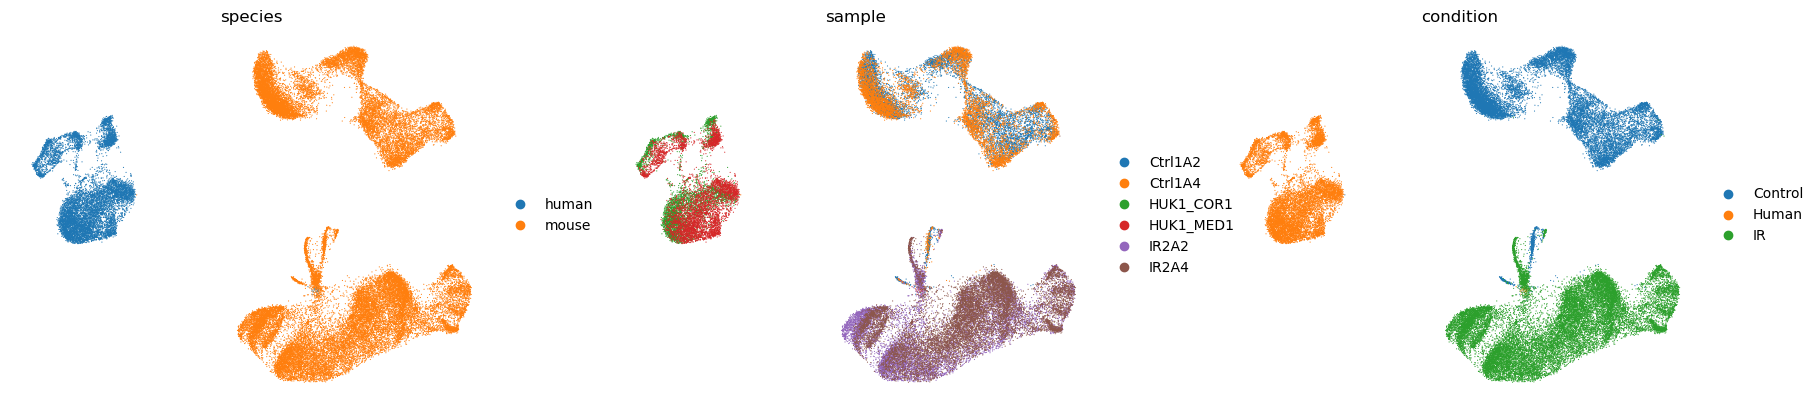


Running Harmony on 45753 tubules x 2114 selected features

Samples per species:
species  sample   
human    HUK1_MED1     5406
         HUK1_COR1     4539
mouse    IR2A4        11154
         IR2A2        10395
         Ctrl1A2       7545
         Ctrl1A4       6714
Name: count, dtype: int64
Running R Harmony on 45753 cells with 40 PCs...
  Batch key: sample
  Unique batches: ['Ctrl1A2' 'Ctrl1A4' 'HUK1_COR1' 'HUK1_MED1' 'IR2A2' 'IR2A4']
  Theta: 7, Lambda: 1, Max iter: 30
  R matrix shape (should be PCs x cells): 40 x 45753


R callback write-console: Initializing state using k-means centroids initialization
  
R callback write-console: Harmony 1/10
  
R callback write-console: 0%   10   20   30   40   50   60   70   80   90   100%
  
R callback write-console: [----|----|----|----|----|----|----|----|----|----|
  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write

  Harmony result shape (PCs x cells): 45753 x 40
  Harmony done. Final embedding shape: (45753, 40)


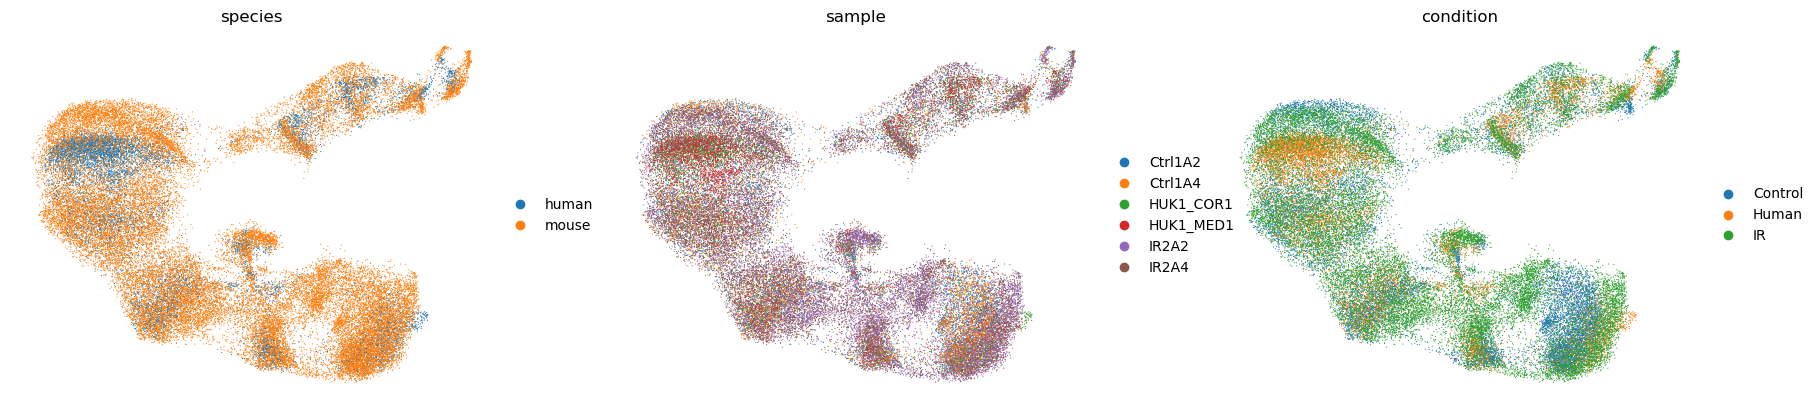

ok: PT_S1: ['Slc5a12', 'Slc22a8', 'Slc13a3', 'Slc22a6', 'Prodh2', 'Slc5a2']
ok: PT_S2: ['Slc5a12', 'Slc34a1', 'Slc13a3', 'Slc22a6', 'Slc22a7']
ok: PT_S3: ['Slc22a7']
ok: DTL1: ['Id1', 'Jag1']
ok: DTL2: ['Aqp1', 'Lrp2', 'Vcam1']
ok: DTL3: ['Cldn4']
ok: ATL: ['Tacstd2', 'Cldn4']
ok: M_TAL: ['Umod', 'Slc12a1', 'Cldn10', 'Egf']
ok: C_TAL: ['Umod', 'Slc12a1', 'Cldn10', 'Bcl6']
ok: DCT1: ['Slc12a3', 'Calb1']
ok: DCT2: ['Slc12a3', 'Calb1', 'Hsd11b2']
ok: CNT: ['Calb1', 'Aqp2', 'Itpkb']
ok: CD_PC: ['Aqp2', 'Aqp3']
ok: CD_IC_A: ['Slc4a1']
ok: CD_IC_B: ['Slc26a4']

Scores created: ['PT_S1_score', 'PT_S2_score', 'PT_S3_score', 'DTL1_score', 'DTL2_score', 'DTL3_score', 'ATL_score', 'M_TAL_score', 'C_TAL_score', 'DCT1_score', 'DCT2_score', 'CNT_score', 'CD_PC_score', 'CD_IC_A_score', 'CD_IC_B_score']


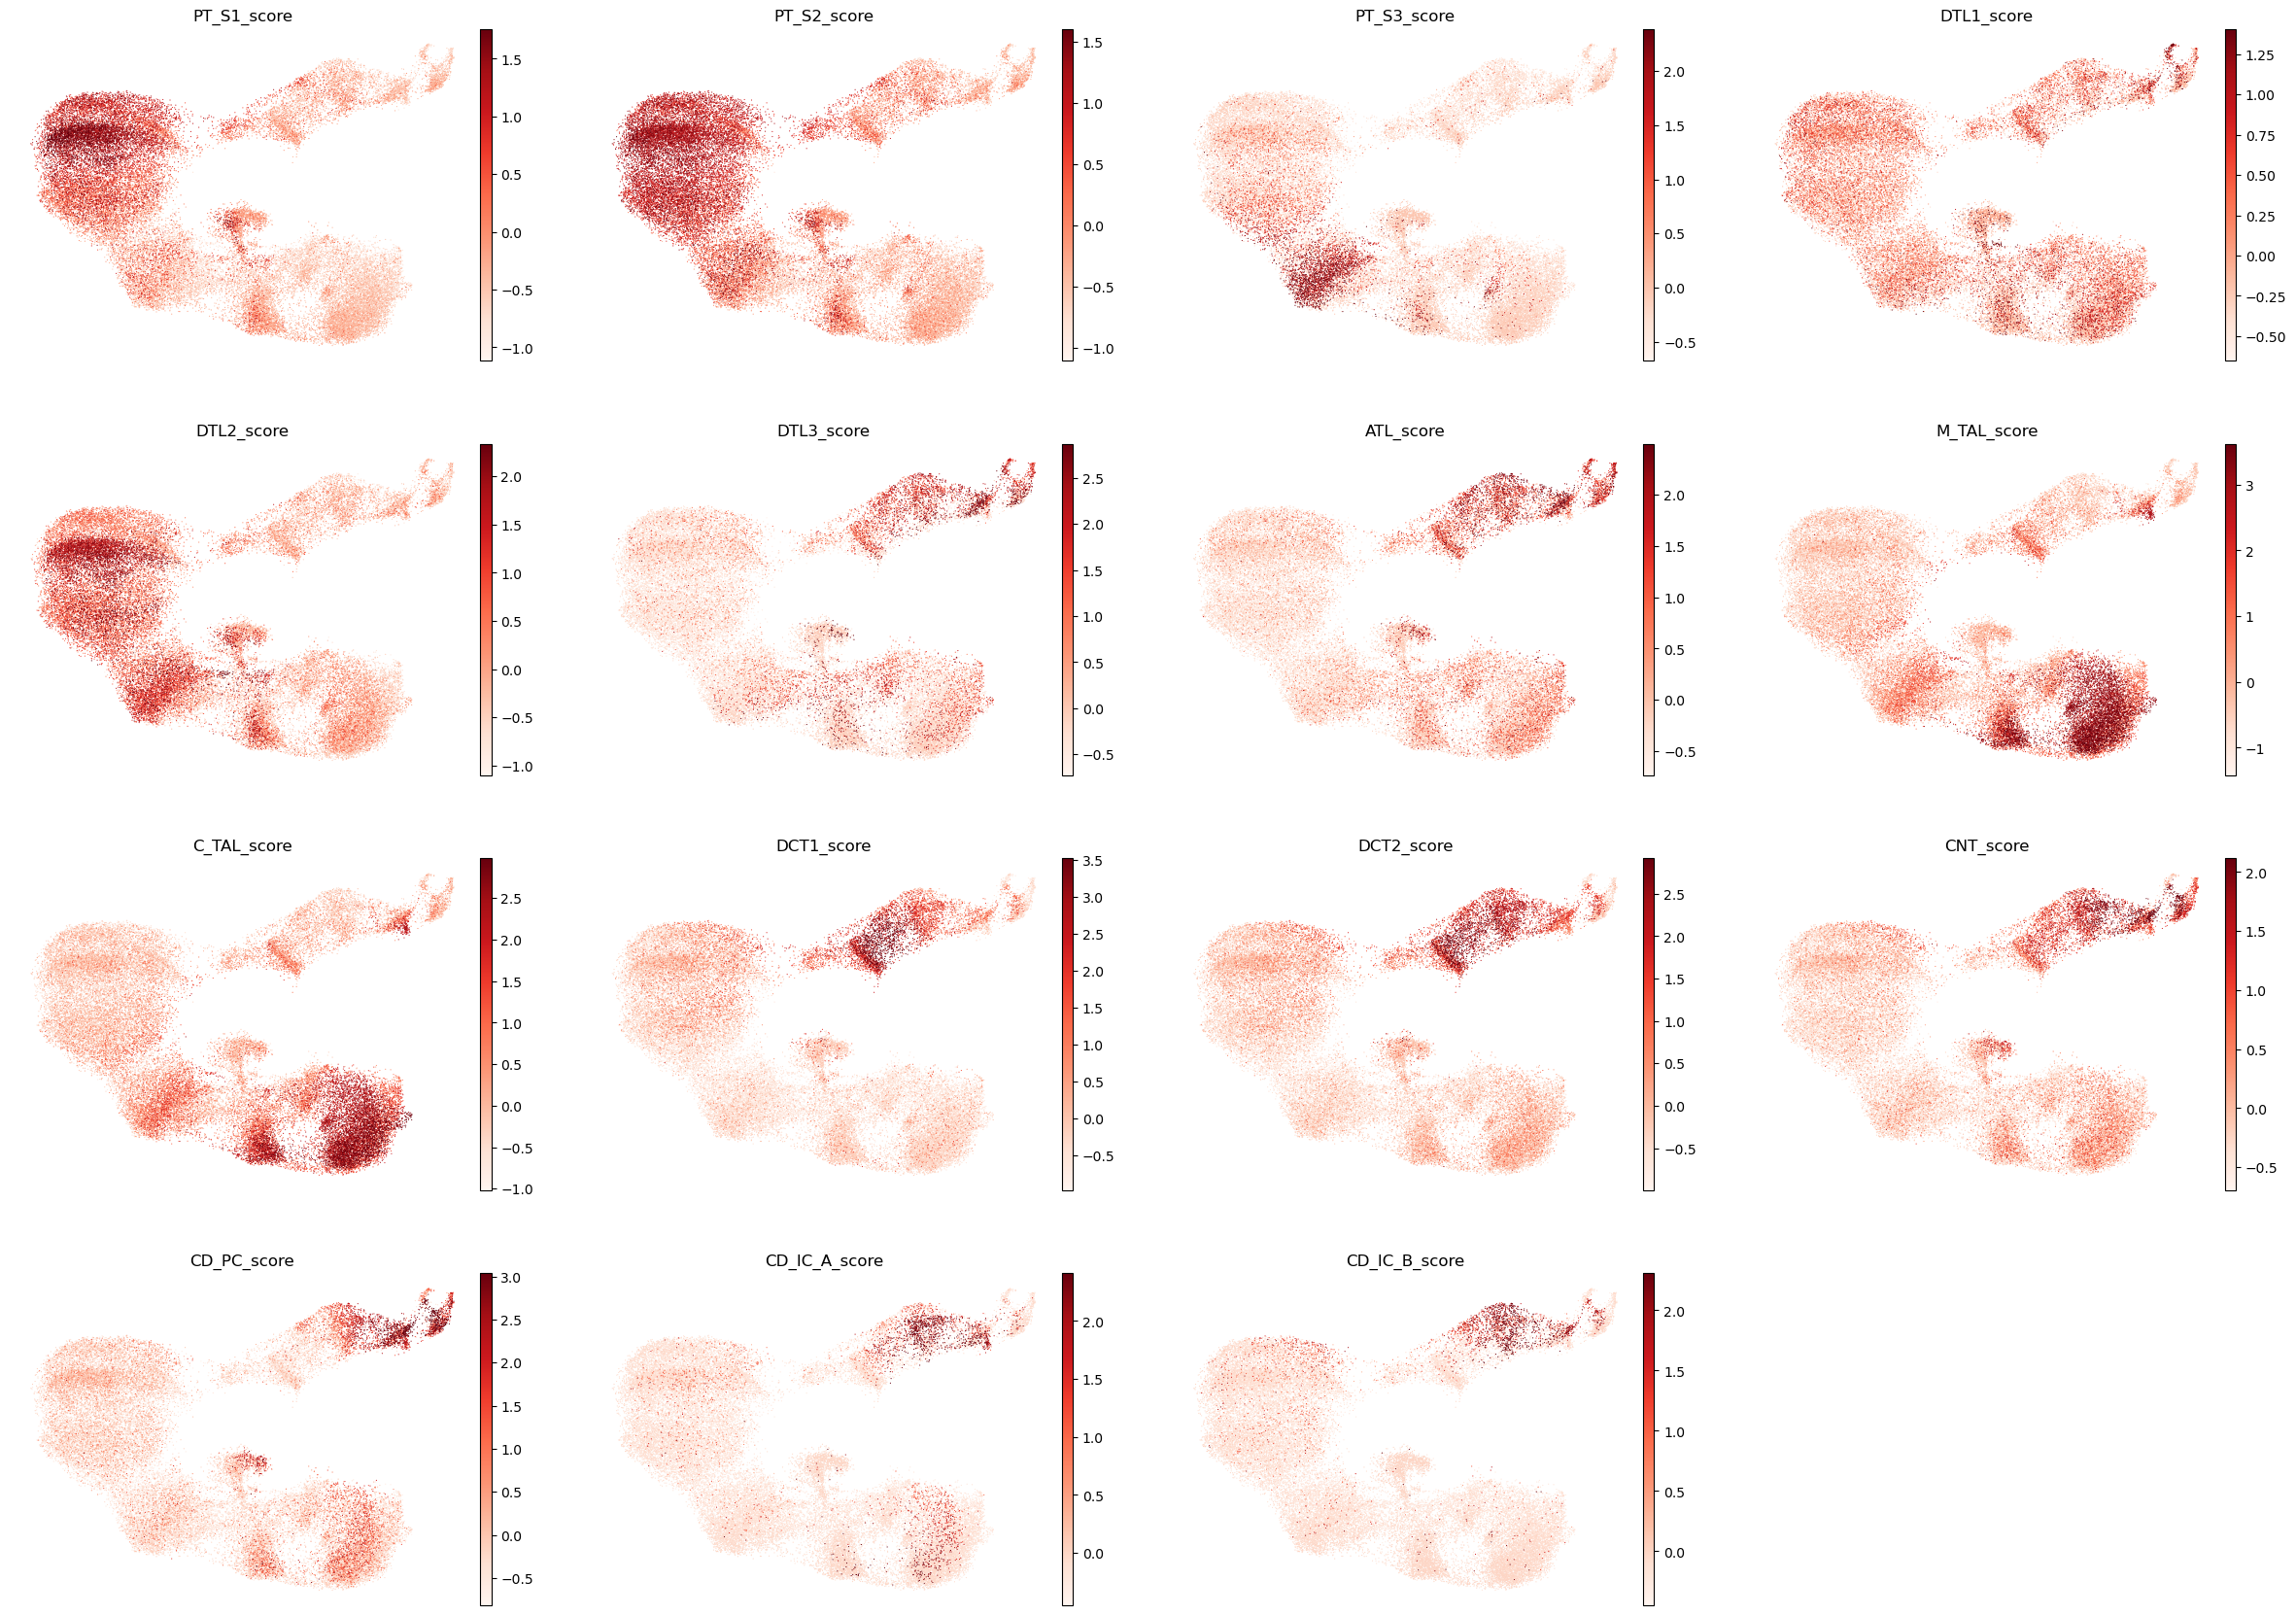


Saved harmonized AnnData to: data/all_tubules_harmony_ortholog_space.h5ad
Final object contains all shared ortholog genes, including mito/ribo genes.
Harmony/PCA used only selected non-mito/ribo tubule-variable genes.


AnnData object with n_obs × n_vars = 45753 × 15736
    obs: 'sample', 'feature_index', 'x_centroid', 'y_centroid', 'n_spots', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'original_obs_name', 'species', 'condition', 'n_genes', 'PT_S1_score', 'PT_S2_score', 'PT_S3_score', 'DTL1_score', 'DTL2_score', 'DTL3_score', 'ATL_score', 'M_TAL_score', 'C_TAL_score', 'DCT1_score', 'DCT2_score', 'CNT_score', 'CD_PC_score', 'CD_IC_A_score', 'CD_IC_B_score'
    var: 'mt', 'ribo', 'exclude_from_harmony_hvg', 'hvg_condition_count', 'highly_variable_for_harmony', 'forced_harmony_marker'
    uns: 'log1p', 'neighbors', 'umap', 'species_colors', 'sample_colors', 'condition_colors'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    layers: 'counts', 'lognorm'
    obsp: 'distances', 'connectivities'

In [5]:
from __future__ import annotations

import os
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri, pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

ro.r('.libPaths(c("~/R/library", .libPaths()))')

PROJECT_DIR = Path.cwd().resolve()
DATA_DIR = PROJECT_DIR / "data"
TUBULE_BY_GENE_DIR = DATA_DIR / "tubule_by_gene"
OUTPUT_PATH = DATA_DIR / "all_tubules_harmony_ortholog_space.h5ad"

HCOP_PATH = Path(
    "/home/edmund/Desktop/kidney-tubule-pseudospace-reconstruction/"
    "processed_data/human_mouse_hcop_fifteen_column.txt.gz"
)

CURATED_KIDNEY_ORTHOLOGS = {
    "SLC5A12": "Slc5a12",
    "SLC22A8": "Slc22a8",
    "SLC13A3": "Slc13a3",
    "SLC22A6": "Slc22a6",
    "PRODH2": "Prodh2",
    "SLC5A2": "Slc5a2",
    "SLC34A1": "Slc34a1",
    "SLC22A7": "Slc22a7",
    "LRP2": "Lrp2",
    "AQP1": "Aqp1",
    "ID1": "Id1",
    "JAG1": "Jag1",
    "VCAM1": "Vcam1",
    "AKR1B1": "Akr1b1",
    "CLDN4": "Cldn4",
    "TACSTD2": "Tacstd2",
    "UMOD": "Umod",
    "SLC12A1": "Slc12a1",
    "CLDN10": "Cldn10",
    "EGF": "Egf",
    "BCL6": "Bcl6",
    "SLC12A3": "Slc12a3",
    "CALB1": "Calb1",
    "PVALB": "Pvalb",
    "HSD11B2": "Hsd11b2",
    "AQP2": "Aqp2",
    "AQP3": "Aqp3",
    "ITPKB": "Itpkb",
    "FXYD4": "Fxyd4",
    "SLC4A1": "Slc4a1",
    "SLC26A4": "Slc26a4",
    "ATP6V1B1": "Atp6v1b1",
}

VALIDATED_MARKERS_MOUSE = {
    "PT_S1": ["Slc5a12", "Slc22a8", "Slc13a3", "Slc22a6", "Prodh2", "Slc5a2"],
    "PT_S2": ["Slc5a12", "Slc34a1", "Slc13a3", "Slc22a6", "Slc22a7"],
    "PT_S3": ["Slc22a7"],
    "DTL1": ["Id1", "Jag1"],
    "DTL2": ["Aqp1", "Lrp2", "Vcam1"],
    "DTL3": ["Akr1b1", "Cldn4"],
    "ATL": ["Tacstd2", "Cldn4"],
    "M_TAL": ["Umod", "Slc12a1", "Cldn10", "Egf"],
    "C_TAL": ["Umod", "Slc12a1", "Cldn10", "Bcl6"],
    "DCT1": ["Slc12a3", "Calb1"],
    "DCT2": ["Slc12a3", "Calb1", "Hsd11b2"],
    "CNT": ["Calb1", "Aqp2", "Itpkb"],
    "CD_PC": ["Aqp2", "Aqp3"],
    "CD_IC_A": ["Slc4a1"],
    "CD_IC_B": ["Slc26a4"],
}


def sample_name_from_path(path: Path) -> str:
    return path.name.replace("_tubule_by_gene.h5ad", "")


def calculate_qc_metrics(adata: ad.AnnData, species: str = "mouse") -> ad.AnnData:
    adata = adata.copy()

    if species == "mouse":
        mito_pattern = "^mt-"
        ribo_pattern = "^Rpl|^Rps"
    else:
        mito_pattern = "^MT-"
        ribo_pattern = "^RPL|^RPS"

    adata.var["mt"] = adata.var_names.str.contains(mito_pattern, regex=True)
    adata.var["ribo"] = adata.var_names.str.contains(ribo_pattern, regex=True)

    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=["mt", "ribo"],
        percent_top=None,
        log1p=False,
        inplace=True,
    )

    print(
        f"    Mito %: mean={adata.obs['pct_counts_mt'].mean():.2f}, "
        f"max={adata.obs['pct_counts_mt'].max():.2f}"
    )
    print(
        f"    Ribo %: mean={adata.obs['pct_counts_ribo'].mean():.2f}, "
        f"max={adata.obs['pct_counts_ribo'].max():.2f}"
    )

    return adata


def annotate_mito_ribo_mouse_symbols(adata: ad.AnnData) -> ad.AnnData:
    """
    After human genes have been converted to mouse-style symbols, annotate
    mitochondrial and ribosomal genes in the shared ortholog gene space.

    These genes are KEPT in the final object, but excluded from HVG/PCA/Harmony.
    """
    adata = adata.copy()

    mito_pattern = "^mt-"
    ribo_patterns = ["^Rpl", "^Rps", "^Mrpl", "^Mrps"]

    adata.var["mt"] = adata.var_names.str.contains(mito_pattern, regex=True)

    ribo = pd.Series(False, index=adata.var_names)
    for pattern in ribo_patterns:
        ribo = ribo | adata.var_names.str.contains(pattern, regex=True)

    adata.var["ribo"] = ribo.values
    adata.var["exclude_from_harmony_hvg"] = adata.var["mt"] | adata.var["ribo"]

    print("\nGene annotations in combined ortholog space:")
    print(f"  Mito genes kept in final object: {int(adata.var['mt'].sum())}")
    print(f"  Ribo genes kept in final object: {int(adata.var['ribo'].sum())}")
    print(
        f"  Genes excluded only from Harmony HVG selection: "
        f"{int(adata.var['exclude_from_harmony_hvg'].sum())}"
    )

    return adata


def get_ortholog_map_with_curated() -> dict[str, str]:
    print("=" * 60)
    print("BUILDING ORTHOLOG MAP")
    print("=" * 60)

    print(f"\n1. Curated kidney orthologs: {len(CURATED_KIDNEY_ORTHOLOGS)} genes")
    print("\n2. Fetching HCOP database...")

    df = pd.read_csv(HCOP_PATH, sep="\t", compression="gzip", low_memory=False)

    df = df[
        (df["human_symbol"].notna())
        & (df["mouse_symbol"].notna())
        & (df["human_symbol"] != "-")
        & (df["mouse_symbol"] != "-")
    ]

    print(f"   Total valid HCOP pairs: {len(df)}")

    df["n_sources"] = df["support"].apply(
        lambda x: len(str(x).split(",")) if pd.notna(x) else 0
    )
    df["same_name"] = df["human_symbol"].str.upper() == df["mouse_symbol"].str.upper()
    df["priority"] = df["same_name"].astype(int) * 100 + df["n_sources"]

    df = df.sort_values("priority", ascending=False)

    df_best = df.drop_duplicates(subset="human_symbol", keep="first")
    df_final = df_best.drop_duplicates(subset="mouse_symbol", keep="first")

    print(f"   HCOP genes after dedup: {len(df_final)}")

    hcop_map = dict(zip(df_final["human_symbol"], df_final["mouse_symbol"]))

    # Curated kidney marker orthologs override HCOP when present.
    ortholog_map = {**hcop_map, **CURATED_KIDNEY_ORTHOLOGS}

    print(f"\n3. Final ortholog map: {len(ortholog_map)} genes")
    print("\n4. Verifying curated markers:")
    for human_gene, mouse_gene in CURATED_KIDNEY_ORTHOLOGS.items():
        print(f"   {human_gene} -> {mouse_gene}")

    return ortholog_map


def convert_human_to_mouse_symbols(
    adata: ad.AnnData,
    ortholog_map: dict[str, str],
) -> ad.AnnData:
    adata = adata.copy()

    valid = [g for g in adata.var_names if g in ortholog_map]
    new_names = [ortholog_map[g] for g in valid]

    # Deduplicate mouse symbols after human-to-mouse mapping.
    if len(new_names) != len(set(new_names)):
        seen = set()
        unique_idx = []
        unique_names = []

        for i, name in enumerate(new_names):
            if name not in seen:
                seen.add(name)
                unique_idx.append(i)
                unique_names.append(name)

        valid = [valid[i] for i in unique_idx]
        new_names = unique_names

    adata = adata[:, valid].copy()
    adata.var["original_human_symbol"] = valid
    adata.var_names = pd.Index(new_names)

    return adata


def filter_mouse_to_ortholog_space(
    adata: ad.AnnData,
    mouse_genes_in_map: set[str],
) -> ad.AnnData:
    adata = adata.copy()
    valid = [g for g in adata.var_names if g in mouse_genes_in_map]
    return adata[:, valid].copy()


def load_and_process_samples(
    data_dir: Path,
    files: list[str],
    ortholog_map: dict[str, str],
    mouse_genes_in_map: set[str],
) -> dict[str, ad.AnnData]:
    """
    Load each sample and convert into shared mouse-symbol ortholog space.

    Important:
    - Mito/ribo genes are NOT removed here.
    - They remain in the final saved object.
    - They are only excluded later from HVG/PCA/Harmony feature selection.
    """
    adatas_ortho = {}

    for f in files:
        name = sample_name_from_path(Path(f))
        print(f"\nProcessing: {name}")

        adata = sc.read_h5ad(os.path.join(data_dir, f))

        if "counts" in adata.layers:
            adata.X = adata.layers["counts"].copy()

        is_human = "HUK" in name
        species = "human" if is_human else "mouse"

        adata = calculate_qc_metrics(adata, species=species)

        adata.obs["original_obs_name"] = adata.obs_names.astype(str).copy()
        adata.obs_names = pd.Index([f"{name}_{obs}" for obs in adata.obs_names])

        adata.obs["sample"] = name
        adata.obs["species"] = species

        if is_human:
            adata.obs["condition"] = "Human"
        elif "Ctrl" in name:
            adata.obs["condition"] = "Control"
        elif "IR" in name:
            adata.obs["condition"] = "IR"
        else:
            adata.obs["condition"] = "Unknown"

        if is_human:
            adata_ortho = convert_human_to_mouse_symbols(
                adata.copy(),
                ortholog_map,
            )
        else:
            adata_ortho = filter_mouse_to_ortholog_space(
                adata.copy(),
                mouse_genes_in_map,
            )

        print(f"    Ortholog space: {adata_ortho.n_vars} genes")
        adatas_ortho[name] = adata_ortho

    return adatas_ortho


def combine_adatas(adatas_ortho: dict[str, ad.AnnData]) -> ad.AnnData:
    """
    Inner join keeps the shared ortholog gene space across samples.
    This still keeps all genes that are shared orthologs after mapping;
    no mito/ribo or low-expression gene filtering is done here.
    """
    adata = sc.concat(list(adatas_ortho.values()), join="inner")

    if not adata.obs_names.is_unique:
        adata.obs_names_make_unique()

    if not adata.var_names.is_unique:
        adata.var_names_make_unique()

    return adata


def select_harmony_hvgs_by_condition(
    adata: ad.AnnData,
    group_key: str = "condition",
    groups: tuple[str, ...] = ("Human", "Control", "IR"),
    min_groups: int = 2,
    min_mean: float = 0.0125,
    max_mean: float = 3,
    min_disp: float = 0.5,
    force_genes: set[str] | None = None,
) -> ad.AnnData:
    """
    Select Harmony genes by running HVG selection separately inside each broad
    biological group: Human, Control, and IR.

    Rationale:
    - We want genes variable among tubule types within each group.
    - We do NOT want HVGs dominated only by AKI-vs-control or human-vs-mouse differences.
    - Genes selected in at least min_groups groups are used for Harmony.
    - Curated nephron markers are forced into the Harmony set if present.
    - Mito/ribo genes are kept in the final object but excluded from Harmony HVGs.
    """
    adata = adata.copy()

    if force_genes is None:
        force_genes = set()

    eligible_mask = ~adata.var["exclude_from_harmony_hvg"].values
    eligible_genes = set(adata.var_names[eligible_mask])

    hvg_counts = pd.Series(0, index=adata.var_names, dtype=int)

    print("\n" + "=" * 60)
    print("SELECTING HARMONY HVGs WITHIN EACH CONDITION GROUP")
    print("=" * 60)
    print(f"Groups: {groups}")
    print(f"Minimum groups required: {min_groups}")
    print(f"Eligible non-mito/ribo genes: {len(eligible_genes)}")

    for group in groups:
        idx = adata.obs[group_key].astype(str).values == group

        if idx.sum() < 20:
            print(f"  Skipping {group}: only {idx.sum()} tubules")
            continue

        sub = adata[idx, list(eligible_genes)].copy()
        sub.X = sub.layers["lognorm"].copy()

        unique_samples = sub.obs["sample"].astype(str).nunique()
        batch_key = "sample" if unique_samples > 1 else None

        print(
            f"\n  {group}: {sub.n_obs} tubules x {sub.n_vars} eligible genes "
            f"({unique_samples} sample(s), batch_key={batch_key})"
        )

        sc.pp.highly_variable_genes(
            sub,
            min_mean=min_mean,
            max_mean=max_mean,
            min_disp=min_disp,
            batch_key=batch_key,
            flavor="seurat",
        )

        group_hvgs = set(sub.var_names[sub.var["highly_variable"]])
        hvg_counts.loc[list(group_hvgs)] += 1

        print(f"    HVGs in {group}: {len(group_hvgs)}")

    force_present = sorted(g for g in force_genes if g in adata.var_names)

    selected = hvg_counts >= min_groups

    # Force curated nephron markers into the integration feature set.
    if force_present:
        selected.loc[force_present] = True

    # Never use mito/ribo for Harmony feature selection.
    selected = selected & ~adata.var["exclude_from_harmony_hvg"]

    adata.var["hvg_condition_count"] = hvg_counts.values
    adata.var["highly_variable_for_harmony"] = selected.values
    adata.var["forced_harmony_marker"] = adata.var_names.isin(force_present)

    print("\nHarmony HVG summary:")
    print(f"  Genes variable in >= {min_groups} groups: {int((hvg_counts >= min_groups).sum())}")
    print(f"  Forced curated markers present: {len(force_present)}")
    print(f"  Final Harmony feature genes: {int(adata.var['highly_variable_for_harmony'].sum())}")

    if int(adata.var["highly_variable_for_harmony"].sum()) < 500:
        print(
            "\nWARNING: fewer than 500 Harmony features selected. "
            "Consider lowering min_groups to 1 or min_disp to 0.25."
        )

    return adata


def run_harmony_rpy2(
    adata: ad.AnnData,
    batch_key: str,
    n_pcs: int = 40,
    theta: float = 2,
    lambda_val: float = 1,
    max_iter: int = 30,
    tau: int = 1000,
) -> ad.AnnData:
    harmony = importr("harmony")
    base = importr("base")

    pca_embeddings = adata.obsm["X_pca"][:, :n_pcs].copy()

    n_cells = pca_embeddings.shape[0]
    n_pcs_actual = pca_embeddings.shape[1]
    batch_labels = adata.obs[batch_key].values.astype(str)

    print(f"Running R Harmony on {n_cells} cells with {n_pcs_actual} PCs...")
    print(f"  Batch key: {batch_key}")
    print(f"  Unique batches: {np.unique(batch_labels)}")
    print(f"  Theta: {theta}, Lambda: {lambda_val}, Max iter: {max_iter}")

    with localconverter(ro.default_converter + numpy2ri.converter + pandas2ri.converter):
        r_pca_cells_by_pcs = ro.r.matrix(
            pca_embeddings.flatten(order="C"),
            nrow=n_cells,
            ncol=n_pcs_actual,
            byrow=True,
        )

        r_pca_t = base.t(r_pca_cells_by_pcs)

        r_meta = ro.DataFrame({batch_key: ro.StrVector(batch_labels)})

        print(
            f"  R matrix shape (should be PCs x cells): "
            f"{base.nrow(r_pca_t)[0]} x {base.ncol(r_pca_t)[0]}"
        )

        harmony_result = harmony.HarmonyMatrix(
            r_pca_t,
            r_meta,
            batch_key,
            tau=tau,
            do_pca=False,
            theta=float(theta),
            lambda_=float(lambda_val),
            max_iter_harmony=int(max_iter),
            verbose=True,
        )

        result_nrow = base.nrow(harmony_result)[0]
        result_ncol = base.ncol(harmony_result)[0]

        print(f"  Harmony result shape (PCs x cells): {result_nrow} x {result_ncol}")

        harmony_array = np.array(harmony_result)

        if harmony_array.shape == (n_pcs_actual, n_cells):
            harmony_embeddings = harmony_array.T
        elif harmony_array.shape == (n_cells, n_pcs_actual):
            harmony_embeddings = harmony_array
        else:
            print(f"  Warning: unexpected shape {harmony_array.shape}, reshaping...")
            harmony_embeddings = harmony_array.reshape(n_pcs_actual, n_cells).T

    print(f"  Harmony done. Final embedding shape: {harmony_embeddings.shape}")

    assert harmony_embeddings.shape == (n_cells, n_pcs_actual), (
        f"Shape mismatch: expected ({n_cells}, {n_pcs_actual}), "
        f"got {harmony_embeddings.shape}"
    )

    adata.obsm["X_harmony"] = harmony_embeddings

    return adata


# ---------------------------------------------------------------------
# Main pipeline
# ---------------------------------------------------------------------

files = sorted(path.name for path in TUBULE_BY_GENE_DIR.glob("*_tubule_by_gene.h5ad"))

if not files:
    raise FileNotFoundError(f"No tubule-by-gene AnnData files found in {TUBULE_BY_GENE_DIR}")

ortholog_map = get_ortholog_map_with_curated()
mouse_genes_in_map = set(ortholog_map.values())

adatas_ortho = load_and_process_samples(
    TUBULE_BY_GENE_DIR,
    files,
    ortholog_map,
    mouse_genes_in_map,
)

adata_combined = combine_adatas(adatas_ortho)

print(f"\n{'=' * 60}")
print(f"COMBINED DATA: {adata_combined.n_obs} tubules x {adata_combined.n_vars} shared ortholog genes")
print("=" * 60)

adata_combined = annotate_mito_ribo_mouse_symbols(adata_combined)

print("\nVERIFYING VALIDATED MARKERS:")
print("-" * 40)

total_found = 0
total_markers = 0

for cell_type, genes in VALIDATED_MARKERS_MOUSE.items():
    found = [g for g in genes if g in adata_combined.var_names]
    missing = [g for g in genes if g not in adata_combined.var_names]

    total_found += len(found)
    total_markers += len(genes)

    status = "ok" if len(missing) == 0 else "partial" if len(found) > 0 else "missing"

    print(f"{status}: {cell_type} {len(found)}/{len(genes)}")

    if missing:
        print(f"  Missing: {missing}")

print(f"\nTotal: {total_found}/{total_markers} markers found ({100 * total_found / total_markers:.1f}%)")

print(f"\n{'=' * 60}")
print("PREPROCESSING")
print("=" * 60)

# Keep all genes in the final object.
# Do not run sc.pp.filter_genes here.

# Optional tubule-level filter after ortholog mapping.
# This removes very low-information tubules but does NOT remove genes.
print(f"Before cell filtering: {adata_combined.n_obs} tubules x {adata_combined.n_vars} genes")
sc.pp.filter_cells(adata_combined, min_genes=100)
print(f"After cell filtering: {adata_combined.n_obs} tubules x {adata_combined.n_vars} genes")

# Store raw counts for all retained genes.
adata_combined.layers["counts"] = adata_combined.X.copy()

# Normalize/log-transform all genes.
sc.pp.normalize_total(adata_combined, target_sum=1e4)
sc.pp.log1p(adata_combined)

# Keep full log-normalized expression for all genes.
adata_combined.layers["lognorm"] = adata_combined.X.copy()

# Force curated nephron markers into Harmony feature set if present.
curated_marker_genes = set()
for genes in VALIDATED_MARKERS_MOUSE.values():
    curated_marker_genes.update(genes)

# Select Harmony HVGs within Human, Control, and IR separately.
# Use genes selected in at least 2 groups, plus curated markers.
adata_combined = select_harmony_hvgs_by_condition(
    adata_combined,
    group_key="condition",
    groups=("Human", "Control", "IR"),
    min_groups=2,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5,
    force_genes=curated_marker_genes,
)

hvg_col = "highly_variable_for_harmony"

print(f"\nFinal Harmony features: {int(adata_combined.var[hvg_col].sum())}")
print("HVG condition-count distribution:")
print(adata_combined.var["hvg_condition_count"].value_counts().sort_index())


# ---------------------------------------------------------------------
# Pre-Harmony diagnostic UMAP
# ---------------------------------------------------------------------

adata_pre_harmony = adata_combined[:, adata_combined.var[hvg_col]].copy()
adata_pre_harmony.X = adata_pre_harmony.layers["lognorm"].copy()
adata_pre_harmony.obs["sample"] = adata_pre_harmony.obs["sample"].astype(str)

print(
    f"\nPre-Harmony PCA/UMAP on "
    f"{adata_pre_harmony.n_obs} tubules x {adata_pre_harmony.n_vars} Harmony features"
)

sc.tl.pca(adata_pre_harmony, n_comps=50)
sc.pp.neighbors(adata_pre_harmony, n_neighbors=25, use_rep="X_pca")
sc.tl.umap(adata_pre_harmony, min_dist=0.3, spread=1.0)

sc.pl.umap(
    adata_pre_harmony,
    color=["species", "sample", "condition"],
    ncols=3,
    frameon=False,
)


# ---------------------------------------------------------------------
# Harmony integration
# ---------------------------------------------------------------------

adata_hvg = adata_combined[:, adata_combined.var[hvg_col]].copy()
adata_hvg.X = adata_hvg.layers["lognorm"].copy()

print(f"\nRunning Harmony on {adata_hvg.n_obs} tubules x {adata_hvg.n_vars} selected features")
print("\nSamples per species:")
print(adata_hvg.obs.groupby("species")["sample"].value_counts())

sc.tl.pca(adata_hvg, n_comps=50)

adata_hvg = run_harmony_rpy2(
    adata_hvg,
    batch_key="sample",
    n_pcs=40,
    theta=7,
    lambda_val=1,
    max_iter=30,
)

# Store embeddings on the full-gene object.
adata_combined.obsm["X_harmony"] = adata_hvg.obsm["X_harmony"].copy()
adata_combined.obsm["X_pca"] = adata_hvg.obsm["X_pca"].copy()

# Neighbors and UMAP use Harmony embedding, but the object still contains all genes.
sc.pp.neighbors(adata_combined, use_rep="X_harmony", n_neighbors=25)
sc.tl.umap(adata_combined, min_dist=0.3, spread=1.0)

sc.pl.umap(
    adata_combined,
    color=["species", "sample", "condition"],
    ncols=3,
    frameon=False,
)


# ---------------------------------------------------------------------
# Marker scoring on full-gene log-normalized object
# ---------------------------------------------------------------------

for cell_type, genes in VALIDATED_MARKERS_MOUSE.items():
    genes_present = [g for g in genes if g in adata_combined.var_names]

    if genes_present:
        sc.tl.score_genes(
            adata_combined,
            gene_list=genes_present,
            score_name=f"{cell_type}_score",
            use_raw=False,
        )
        print(f"ok: {cell_type}: {genes_present}")
    else:
        print(f"missing: {cell_type}: no markers in var_names")

score_cols = [col for col in adata_combined.obs.columns if col.endswith("_score")]

print(f"\nScores created: {score_cols}")

if score_cols:
    sc.pl.umap(
        adata_combined,
        color=score_cols,
        ncols=4,
        frameon=False,
        vmax="p99",
        cmap="Reds",
    )


# ---------------------------------------------------------------------
# Save final object
# ---------------------------------------------------------------------

adata_combined.write(OUTPUT_PATH)

print(f"\nSaved harmonized AnnData to: {OUTPUT_PATH.relative_to(PROJECT_DIR)}")
print("Final object contains all shared ortholog genes, including mito/ribo genes.")
print("Harmony/PCA used only selected non-mito/ribo tubule-variable genes.")

adata_combined